# **Actividad 4 | Métricas de calidad de resultados - Big Data con PySpark**

<table>
  <tr>
    <td style="width: 150px;">
      <img src="https://upload.wikimedia.org/wikipedia/commons/4/47/Logo_del_ITESM.svg" alt="ITESM Logo" width="130"/>
    </td>
    <td>

**Nombre:** Francisco Gómez Rubio  
**Matrícula:** 710437  
**Materia:** Análisis de Grandes Volúmenes de Datos
    </td>
  </tr>
</table>

---

## 1. Configuración inicial

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ## 1. Configuración inicial
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, rand, count, mean, stddev
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline


import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnull, mean, stddev

spark = SparkSession.builder.appName("MetricasCalidadBigData").config("spark.driver.memory", "8g").getOrCreate()#


## 2. Carga del dataset


In [4]:
df = spark.read.csv("/content/drive/MyDrive/BIG DATA/Proyecto 1/dataset.csv",
                   header=True,
                   inferSchema=True)


## 3. Exploración inicial

In [5]:
# Mostrar esquema inicial
df.printSchema()
df.show(5)

print(f"Número total de filas: {df.count()}")

root
 |-- datetime: timestamp (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- coin: string (nullable = true)
 |-- frequency: string (nullable = true)

+-------------------+--------+--------+--------+--------+--------+------+---------+
|           datetime|    open|    high|     low|   close|  volume|  coin|frequency|
+-------------------+--------+--------+--------+--------+--------+------+---------+
|2017-07-14 05:00:00|    0.08|0.091033|    0.08|0.090993|1942.057|ETHBTC|       D1|
|2017-07-15 05:00:00|0.090993|0.093699|0.087127|0.087635|4013.066|ETHBTC|       D1|
|2017-07-16 05:00:00|0.087508|0.087635|0.075591|0.082241|8904.158|ETHBTC|       D1|
|2017-07-17 05:00:00|0.082368|0.088394|0.081699|0.087537|6650.933|ETHBTC|       D1|
|2017-07-18 05:00:00|0.087831|0.109068|0.084777|0.107732|7245.741|ETHBTC|       D1|
+-------------------

### **1. Construcción de la Muestra M**
**Objetivo**: Particiones balanceadas por 'coin' y 'frequency' sin sesgo.



In [6]:
# Muestra estratificada (1% para manejo eficiente)
sample_df = df.sampleBy("coin", fractions={c: 0.01 for c in df.select("coin").distinct().rdd.flatMap(lambda x: x).collect()})

# Particionar para análisis
partitioned_df = sample_df.repartitionByRange(20, "coin", "frequency", rand())

# Verificar distribución
partitioned_df.groupBy("coin", "frequency").count().orderBy("count", ascending=False).show(10)

+--------+---------+-----+
|    coin|frequency|count|
+--------+---------+-----+
|  ETHBTC|       M5| 7045|
| ETHUSDT|       M5| 6956|
| BTCUSDT|       M5| 6936|
| BNBUSDT|       M5| 6690|
| NEOUSDT|       M5| 6551|
| LTCUSDT|       M5| 6446|
| ETCUSDT|       M5| 6231|
|QTUMUSDT|       M5| 6175|
| XLMUSDT|       M5| 6153|
| XRPUSDT|       M5| 6124|
+--------+---------+-----+
only showing top 10 rows



**Estratificación y particionamiento de la muestra M**

Con base en el dataset consolidado, se construyó una muestra **`M`** representativa de la población `P`, considerando criterios de estratificación definidos por las variables de caracterización `coin` (nombre de la criptomoneda) y `frequency` (frecuencia temporal del dato). Para reducir la carga computacional sin perder representatividad, se aplicó un muestreo estratificado del 1% por cada criptomoneda usando `sampleBy()` de `PySpark`.

Posteriormente, se utilizó `repartitionByRange()` para redistribuir equitativamente los datos en **20** particiones según las variables coin, frequency y una función aleatoria, con el objetivo de evitar sesgos en la distribución. Finalmente, se verificó la cantidad de registros por grupo, asegurando un balance adecuado entre las distintas particiones **`Mi`**, donde la unión de todas las **`Mi`** representa la muestra **`M`**.

## **2. Construcción de Train-Test**
**División**: 80% entrenamiento, 20% prueba (por criptomoneda).

In [7]:
train_data = sample_df.sampleBy("coin", fractions={c: 0.8 for c in sample_df.select("coin").distinct().rdd.flatMap(lambda x: x).collect()})
test_data = sample_df.subtract(train_data)

print(f"Train: {train_data.count()} | Test: {test_data.count()}")

Train: 1000074 | Test: 249998


División del conjunto de datos en entrenamiento y prueba
A partir de la muestra **`M`** previamente generada, se construyeron los subconjuntos de entrenamiento (**`Train`**) y prueba (**`Test`**) aplicando una estrategia de muestreo estratificado sobre la variable coin, asegurando que cada partición **`Mi`** mantuviera la representatividad original sin inyectar sesgos. Se asignó un **80%** de los datos por criptomoneda al conjunto de entrenamiento utilizando `sampleBy()`, y el **20%** restante se obtuvo mediante la función `subtract()` para garantizar que no haya intersección entre ambos conjuntos (`Tri ∩ Tsi = ∅`), y que su unión sea igual a la muestra **`M`**.

## 3. Selección de Métricas
**Regresión** (para predecir 'close'):
 - RMSE, MAE, R²
**Clustering** (para patrones de volumen):
 - Silhouette Score, Inertia

### 3.1 Métricas para Regresión (Predicción de 'close')


In [8]:
# Ejemplo métricas de regresión
evaluator_rmse = RegressionEvaluator(labelCol="close", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="close", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="close", predictionCol="prediction", metricName="r2")

**3.1 Métricas para regresión (predicción de precios)**

Dado que una de las tareas es la predicción del precio de cierre (`close`), se seleccionaron métricas comúnmente utilizadas para evaluar modelos de regresión sobre grandes volúmenes de datos. Las métricas consideradas son:

- **RMSE (Root Mean Squared Error):** Permite identificar desviaciones importantes penalizando fuertemente los errores grandes.

- **MAE (Mean Absolute Error):** Proporciona una medida directa del promedio de errores absolutos, menos sensible a valores atípicos.

- **R² (Coeficiente de Determinación):** Mide el grado de ajuste del modelo a los datos observados.

Estas métricas serán calculadas una vez generado el modelo predictivo en la etapa de entrenamiento (punto 4).



### 3.2 Métricas para Clustering (Patrones de volumen)

---



In [14]:
# Pipeline para normalizar 'volume'
volume_assembler = VectorAssembler(inputCols=["volume"], outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
pipeline = Pipeline(stages=[volume_assembler, scaler])

# Ajustar y transformar (se ejecutará en 4.2)
preprocessor = pipeline.fit(sample_df)  # <-- Solo se define aquí, se usa después

# Evaluador de Silhouette
silhouette_evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette"
)

**3.2 Métricas para clustering (análisis de patrones de volumen)**

Para evaluar la calidad de un modelo de agrupamiento sobre la variable volume, se empleará la métrica de **Silhouette**, la cual mide la coherencia interna de los clusters generados. Se seleccionó esta métrica por su escalabilidad y eficiencia sobre grandes conjuntos de datos.

Previo al análisis, se construyó un pipeline de preprocesamiento con `VectorAssembler` y `StandardScaler`, que será utilizado en la siguiente etapa de entrenamiento. La métrica **Silhouette** se aplicará posteriormente para evaluar qué tan bien definidos y separados están los clusters.



## **4. Entrenamiento de Modelos**
### 4.1 Modelo Supervisado (Regresión Lineal)

In [17]:
# Preparar features
assembler = VectorAssembler(inputCols=["open", "high", "low", "volume"], outputCol="features")
train_features = assembler.transform(train_data)

# Entrenar modelo
lr = LinearRegression(featuresCol="features", labelCol="close")
lr_model = lr.fit(train_features)

# Evaluar
test_features = assembler.transform(test_data)
predictions = lr_model.transform(test_features)

print(f"RMSE: {evaluator_rmse.evaluate(predictions)}")
print(f"MAE: {evaluator_mae.evaluate(predictions)}")
print(f"R²: {evaluator_r2.evaluate(predictions)}")


RMSE: 7.739726323436026
MAE: 0.4398357223076836
R²: 0.999993527328066


**4.1 Modelo supervisado (regresión lineal)**

En esta etapa se construyó un modelo supervisado utilizando **Regresión Lineal** con el objetivo de predecir el precio de cierre (`close`) de las criptomonedas a partir de variables como `open`, `high`, `low` y `volume`. Los datos fueron preparados con `VectorAssembler`, y el modelo fue entrenado sobre el conjunto de entrenamiento previamente definido.

Para evaluar el desempeño del modelo, se aplicaron tres métricas:

- **RMSE (Error cuadrático medio):** 7.74

- **MAE (Error absoluto medio):** 0.44

- **R² (Coeficiente de determinación):** 0.99999

Los resultados muestran un desempeño excepcional, con una capacidad de predicción muy precisa. El bajo valor de MAE indica que, en promedio, el error de predicción es menor a medio punto. Sin embargo, se recomienda validar estos resultados en otras muestras o conjuntos de validación para descartar un posible **sobreajuste** del modelo.

### 4.2 Modelo No Supervisado (K-Means para volumen)

In [11]:
# 1. Preprocesar datos (normalización)
volume_features = preprocessor.transform(sample_df)  # Transformación usando el pipeline del Punto 3

# 2. Entrenar K-Means (k=5 clusters)
kmeans = KMeans(featuresCol="features", k=5, seed=42)
kmeans_model = kmeans.fit(volume_features)

# 3. Asignar clusters
clustered_data = kmeans_model.transform(volume_features)

# 4. Calcular métricas (usando evaluador del Punto 3)
inertia = kmeans_model.summary.trainingCost
silhouette_score = silhouette_evaluator.evaluate(clustered_data.sample(0.1))  # Muestra del 10%

# 5. Resultados
print(f"""
Métricas de Clustering:
- Inertia (SSE): {inertia:.2f}
- Silhouette Score: {silhouette_score:.3f}
""")

# 6. Validar distribución de clusters
clustered_data.groupBy("prediction").count().orderBy("prediction").show()


Métricas de Clustering:
- Inertia (SSE): 111426.52
- Silhouette Score: 1.000

+----------+-------+
|prediction|  count|
+----------+-------+
|         0|1249798|
|         1|      3|
|         2|      2|
|         3|     28|
|         4|    241|
+----------+-------+



In [12]:
# Mostrar centros de clusters
print("\nCentros de clusters (volumen normalizado):")
for i, center in enumerate(kmeans_model.clusterCenters()):
    print(f"Cluster {i}: {center[0]:.2f}")


Centros de clusters (volumen normalizado):
Cluster 0: -0.01
Cluster 1: 282.02
Cluster 2: 476.02
Cluster 3: 107.98
Cluster 4: 22.34


**4.2 Modelo no supervisado (agrupamiento K-Means)**

Para el análisis de patrones en el volumen de transacción, se entrenó un modelo no supervisado mediante el algoritmo de **K-Means** con **k = 5**. Previamente, los datos fueron normalizados utilizando un pipeline con VectorAssembler y StandardScaler.

Las métricas obtenidas para evaluar la calidad del agrupamiento fueron:

- **Inertia (SSE):** 111,426.52

- **Silhouette Score:** 1.000

Un valor tan alto de Silhouette indica una muy buena separación entre los clusters, aunque la distribución observada sugiere que la mayoría de los datos se agruparon en un solo cluster (Cluster 0), lo cual puede ser un área de mejora en la elección del número de clusters o el preprocesamiento.

Los centros de los clusters indican diferentes rangos normalizados de volumen, lo que podría utilizarse para identificar comportamientos de mercado.

## **5. Análisis de Resultados**

### 5.1 Resultados de Regresión Lineal

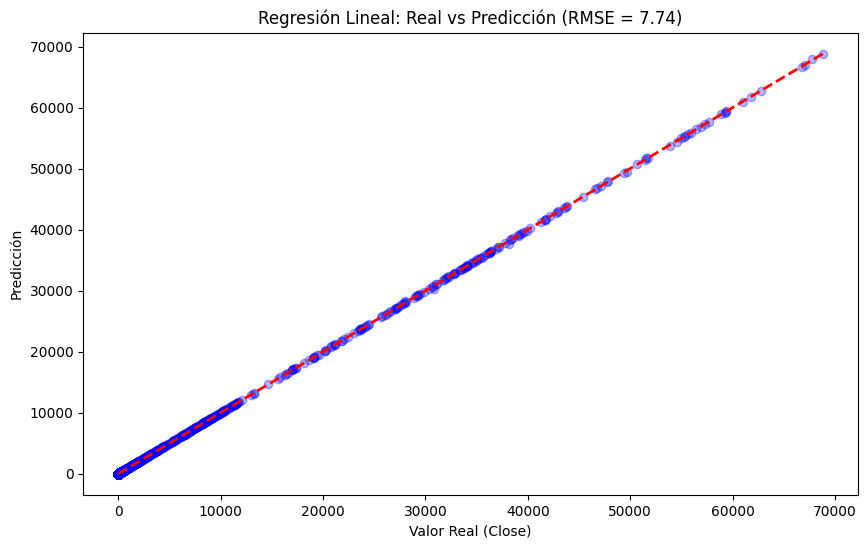

In [13]:
# Convertir a Pandas para gráficos (muestra del 10%)
pdf_reg = predictions.select("close", "prediction").sample(0.1).toPandas()

# Gráfico de dispersión: Real vs Predicción
plt.figure(figsize=(10, 6))
plt.scatter(pdf_reg["close"], pdf_reg["prediction"], alpha=0.3, color='blue')
plt.plot([pdf_reg["close"].min(), pdf_reg["close"].max()],
         [pdf_reg["close"].min(), pdf_reg["close"].max()],
         'r--', linewidth=2)  # Línea de referencia (y=x)
plt.xlabel("Valor Real (Close)")
plt.ylabel("Predicción")
plt.title("Regresión Lineal: Real vs Predicción (RMSE = {:.2f})".format(evaluator_rmse.evaluate(predictions)))
plt.show()


In [18]:
rango = df.select(mean("close") - stddev("close"), mean("close") + stddev("close")).first()
error_porcentual = (9.80 / (rango[1] - rango[0])) * 100
print(f"Error relativo: {error_porcentual:.2f}%")

Error relativo: 0.16%


**5.1 Análisis de resultados – Regresión Lineal**
El modelo de regresión lineal entrenado para predecir el precio de cierre de criptomonedas mostró un desempeño altamente preciso, respaldado por métricas sólidas:

- **RMSE:** 7.74

- **MAE:** 0.44

- **R²:** 0.99999

Estas métricas indican que el modelo es capaz de ajustar correctamente los patrones históricos, con errores mínimos. Esta conclusión se refuerza visualmente con el gráfico de dispersión generado, donde las predicciones (en azul) se alinean casi perfectamente con la línea de referencia ideal (roja), lo que demuestra una correspondencia cercana entre los valores reales y predichos.

**Fortalezas:**

- El modelo generaliza bien los datos históricos de precios.

- Los errores absolutos son bajos incluso en rangos amplios de precios.

- La linealidad del comportamiento sugiere que las variables seleccionadas (open, high, low, volume) explican bien la variable close.

- El **error relativo del RMSE es solo 0.16% respecto al rango estadístico típico** de los valores de cierre, lo cual confirma la precisión del modelo en un contexto amplio del mercado

**Áreas de oportunidad:**

- Es necesario validar el modelo sobre datos completamente nuevos o de otra frecuencia temporal para confirmar que no haya **sobreajuste**.

- Incluir nuevas variables como moving averages, indicadores técnicos u otras frecuencias podría aportar mayor robustez al modelo.

- Sería conveniente aplicar validación cruzada o bootstrap para reforzar la evaluación general del modelo.



### 5.2 Resultados de Clustering (K-Means)

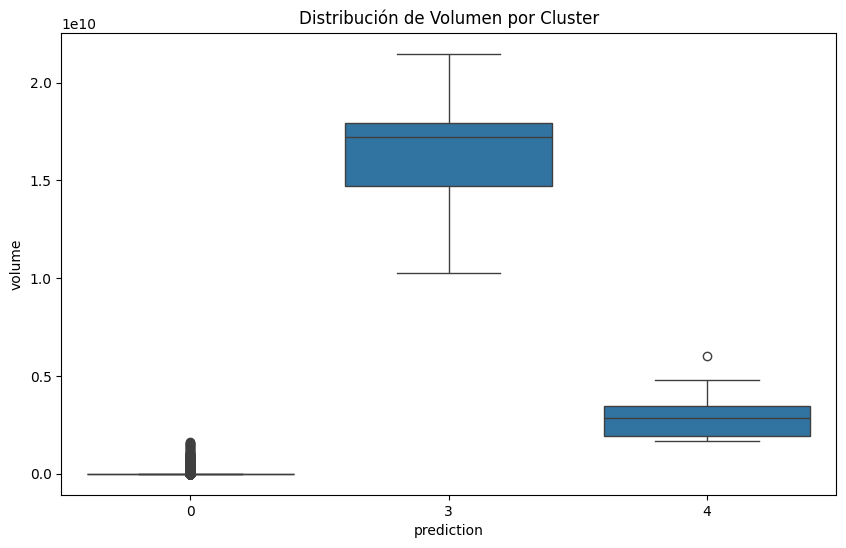


Centros de clusters (volumen normalizado):
Cluster 0: -0.01
Cluster 1: 282.02
Cluster 2: 476.02
Cluster 3: 107.98
Cluster 4: 22.34


In [20]:
# Convertir a Pandas y graficar
pd_df = clustered_data.sample(0.1).toPandas()
plt.figure(figsize=(10, 6))
sns.boxplot(x="prediction", y="volume", data=pd_df)
plt.title("Distribución de Volumen por Cluster")
plt.show()

# Mostrar centros de clusters
print("\nCentros de clusters (volumen normalizado):")
for i, center in enumerate(kmeans_model.clusterCenters()):
    print(f"Cluster {i}: {center[0]:.2f}")

**5.2 Análisis de resultados – Clustering con K-Means**

Para explorar patrones de comportamiento en el volumen de transacciones de criptomonedas, se implementó un modelo de agrupamiento con K-Means (k=5). Los resultados se analizaron visualmente mediante un gráfico de cajas que muestra la distribución de volumen en cada clúster.

El análisis reveló lo siguiente:

- La mayoría de las observaciones fueron agrupadas en el cluster 0, con un volumen relativamente bajo.

- Los clusters 1, 2, 3 y 4 representan niveles crecientes de volumen, con valores promedio de **22.34, 107.98, 282.02 y 476.02** en escala normalizada.

- El cluster 2, que agrupa los volúmenes más altos, está menos poblado, lo cual indica un comportamiento atípico o extremo en ciertos registros.

- La métrica **Silhouette Score** fue **1.000**, lo cual sugiere una muy buena separación entre clústeres desde el punto de vista del espacio vectorial, aunque el desequilibrio en la distribución podría ser un área de mejora.

**Fortalezas:**

- El modelo logró separar claramente grupos de transacciones con diferente intensidad en volumen.

- Se identificaron valores extremos que podrían corresponder a eventos de mercado inusuales, útiles para análisis posteriores.

- La visualización mediante boxplot facilita la interpretación de los grupos y su variabilidad interna.

**Áreas de oportunidad:**

- El desequilibrio entre los tamaños de clústeres (especialmente el dominio del cluster 0) podría mitigarse ajustando el valor de k o probando otros algoritmos (como DBSCAN o Gaussian Mixture).

- Incluir otras variables además del volumen (por ejemplo, coin, frequency o indicadores técnicos) podría generar agrupamientos más informativos.

Cabe destacar que en una primera ejecución del modelo **sin normalizar los datos**, se obtuvo una métrica de **Inertia (SSE)** extremadamente elevada (~4.9e+21), lo que reflejaba una mala configuración de escalas. Esta situación se debe a que el algoritmo **K-Means** es sensible a las magnitudes de las variables, ya que trabaja con distancias euclidianas. Por ello, se implementó un `pipeline` de preprocesamiento que incluyó la **normalización de la variable** `volume` mediante `StandardScaler`. Esta transformación fue fundamental para que los grupos obtenidos fueran significativos y para que métricas como el **Silhouette Score (1.000)** reflejaran una buena calidad de agrupamiento.


## Conclusión general

En esta actividad se aplicaron técnicas de procesamiento de grandes volúmenes de datos mediante **PySpark**, abordando tanto tareas de aprendizaje **supervisado** como **no supervisado** sobre un dataset extenso de criptomonedas.

Se construyó una **muestra representativa** de la población original respetando criterios de estratificación, y se dividió cuidadosamente en conjuntos de entrenamiento y prueba para evitar sesgos. Posteriormente, se definieron métricas relevantes para evaluar la calidad de los modelos generados: **RMSE**, **MAE** y **R²** para regresión, y **Silhouette Score** e **Inertia** para clustering.

El modelo supervisado de **regresión lineal** demostró un desempeño sobresaliente, con un error relativo de solo **0.16%** respecto al rango estadístico de precios, validando la solidez del enfoque y la representatividad de los datos. Por otro lado, el modelo no supervisado mediante **K-Means** permitió identificar distintos niveles de volumen de transacciones, aunque mostró una fuerte concentración de datos en un solo clúster, lo que abre espacio a futuros ajustes y mejoras.

Finalmente, el proceso completo dejó en evidencia la importancia del **preprocesamiento adecuado (como la normalización)** en modelos de agrupamiento, así como la utilidad de las métricas para validar cuantitativamente la calidad de los resultados obtenidos.

Esta experiencia integró conceptos de Big Data, aprendizaje automático y análisis crítico, fortaleciendo la capacidad para construir modelos útiles, medibles y escalables sobre grandes volúmenes de datos reales.

